# Data Efficiency: training-set size vs. test performance

Two views over `artifacts/*/metrics.json`:

1. **Vector-based runs** (`scripts/train.py`) swept across `train_fraction`. x-axis = subsampled training-set size / per-class mean.
2. **LLM few-shot runs** (`scripts/llm_classify.py`) swept across `few_shot.n_per_category`. x-axis is already per-class.

A combined scatter plots both families on a shared *samples-per-category* axis.

Vector-based per-category samples are computed as `n_train / n_classes`, where `n_train` is the size of the (stratified) subsampled training split actually used to refit the final model evaluated on the held-out test set.

In [25]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

ARTIFACTS = Path('..') / 'artifacts'
sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', None)

## Load runs

In [26]:
def _load_run(metrics_path: Path) -> dict | None:
    try:
        m = json.loads(metrics_path.read_text())
    except json.JSONDecodeError:
        return None

    cfg_path = metrics_path.parent / 'config.yaml'
    cfg = {}
    if cfg_path.exists():
        try:
            cfg = yaml.safe_load(cfg_path.read_text()) or {}
        except yaml.YAMLError:
            cfg = {}

    kind = m.get('kind')
    if kind is None:
        kind = 'nested_cv' if 'nested_cv' in m else 'unknown'

    m_llm = m.get('llm') or {}
    c_llm = cfg.get('llm') or {}
    m_prompts = m.get('prompts') or {}
    c_prompts = cfg.get('prompts') or {}
    m_few = m.get('few_shot') or {}
    c_few = cfg.get('few_shot') or {}

    test = m.get('test', {})
    row = {
        'run': metrics_path.parent.name,
        'kind': kind,
        'model': m.get('model') or c_llm.get('name'),
        'featurizer': m.get('featurizer'),
        'data': m.get('data') or (cfg.get('data') or {}).get('name'),
        'n_train': m.get('n_train'),
        'n_test': m.get('n_test'),
        'n_classes': m.get('n_classes'),
        'train_fraction': m.get('train_fraction'),
        'test_accuracy': test.get('accuracy'),
        'test_f1_macro': test.get('f1_macro'),
        'test_f1_weighted': test.get('f1_weighted'),
        'n_per_category': m_few.get('n_per_category', c_few.get('n_per_category')),
        'summary_fraction': m_llm.get('fraction', cfg.get('fraction')),
        'llm_tag': m_llm.get('tag', c_llm.get('tag')),
        'prompts': m_prompts.get('name', c_prompts.get('name')),
    }
    return row


# Vector/Qwen runs live one level under artifacts/; Claude's append-only store
# nests under artifacts/_claude_eval/<run>/, so glob both.
metrics_paths = sorted(ARTIFACTS.glob('*/metrics.json')) + \
                sorted(ARTIFACTS.glob('_claude_eval/*/metrics.json'))
rows = [r for p in metrics_paths if (r := _load_run(p))]
runs = pd.DataFrame(rows)
print(f'Loaded {len(runs)} runs')
runs.head()

Loaded 53 runs


,run,kind,model,featurizer,data,n_train,n_test,n_classes,train_fraction,test_accuracy,test_f1_macro,test_f1_weighted,n_per_category,summary_fraction,llm_tag,prompts
0,complement_nb_tfidf_20ng,nested_cv,complement_nb,tfidf,20ng,15076.0,3770,20,NaN,0.780902,0.767968,0.778907,NaN,NaN,NaN,NaN
1,complement_nb_tfidf_20ng_tf0.01,nested_cv,complement_nb,tfidf,20ng,150.0,3770,20,0.01,0.351724,0.340939,0.347438,NaN,NaN,NaN,NaN
2,complement_nb_tfidf_20ng_tf0.1,nested_cv,complement_nb,tfidf,20ng,1507.0,3770,20,0.10,0.649337,0.629633,0.643195,NaN,NaN,NaN,NaN
3,complement_nb_tfidf_20ng_tf0.25,nested_cv,complement_nb,tfidf,20ng,3769.0,3770,20,0.25,0.722016,0.703007,0.716564,NaN,NaN,NaN,NaN
4,linear_svm_bge_small_20ng,nested_cv,linear_svm,bge_small,20ng,15076.0,3770,20,NaN,0.742175,0.725632,0.737668,NaN,NaN,NaN,NaN


## Derive samples-per-category

- Vector-based (`kind == 'nested_cv'`): `n_train / n_classes`. `train_fraction` defaults to 1.0 for legacy runs.
- LLM few-shot: `n_per_category` directly. Zero-shot runs (`n_per_category == 0`) are kept but not plotted on the log axis.

In [27]:
runs['train_fraction'] = runs['train_fraction'].fillna(1.0)

is_vec = runs['kind'] == 'nested_cv'
is_llm = runs['kind'].isin(['llm_few_shot', 'llm_zero_shot'])

runs['samples_per_category'] = np.nan
runs.loc[is_vec, 'samples_per_category'] = (
    runs.loc[is_vec, 'n_train'].astype(float) / runs.loc[is_vec, 'n_classes'].astype(float)
)
runs.loc[is_llm, 'samples_per_category'] = runs.loc[is_llm, 'n_per_category'].astype(float)

runs['family'] = np.where(is_vec, 'vector', np.where(is_llm, 'llm', 'other'))
runs['variant'] = np.where(
    is_vec,
    runs['model'].astype(str) + '+' + runs['featurizer'].astype(str),
    runs['model'].astype(str) + '|' + runs['prompts'].fillna('').astype(str),
)
runs[['run', 'family', 'variant', 'samples_per_category', 'test_f1_macro']].head()

,run,family,variant,samples_per_category,test_f1_macro
0,complement_nb_tfidf_20ng,vector,complement_nb+tfidf,753.80,0.767968
1,complement_nb_tfidf_20ng_tf0.01,vector,complement_nb+tfidf,7.50,0.340939
2,complement_nb_tfidf_20ng_tf0.1,vector,complement_nb+tfidf,75.35,0.629633
3,complement_nb_tfidf_20ng_tf0.25,vector,complement_nb+tfidf,188.45,0.703007
4,linear_svm_bge_small_20ng,vector,linear_svm+bge_small,753.80,0.725632


## Leaderboard — vector-based across `train_fraction`

In [28]:
vec = runs[is_vec].copy()
vec_board = (
    vec.assign(samples_per_category=vec['samples_per_category'].round(1))
       .sort_values(['variant', 'train_fraction'])
       [[
           'variant', 'model', 'featurizer', 'train_fraction', 'n_train',
           'samples_per_category', 'test_f1_macro', 'test_accuracy',
           'test_f1_weighted', 'run',
       ]]
       .reset_index(drop=True)
)
vec_board.style.background_gradient(
    subset=['test_f1_macro', 'test_accuracy', 'test_f1_weighted'], cmap='Greens'
).format({
    'train_fraction': '{:.3f}',
    'samples_per_category': '{:.1f}',
    'test_f1_macro': '{:.4f}',
    'test_accuracy': '{:.4f}',
    'test_f1_weighted': '{:.4f}',
})

,variant,model,featurizer,train_fraction,n_train,samples_per_category,test_f1_macro,test_accuracy,test_f1_weighted,run
0,complement_nb+tfidf,complement_nb,tfidf,0.010,150.000000,7.5,0.3409,0.3517,0.3474,complement_nb_tfidf_20ng_tf0.01
1,complement_nb+tfidf,complement_nb,tfidf,0.100,1507.000000,75.4,0.6296,0.6493,0.6432,complement_nb_tfidf_20ng_tf0.1
2,complement_nb+tfidf,complement_nb,tfidf,0.250,3769.000000,188.4,0.7030,0.7220,0.7166,complement_nb_tfidf_20ng_tf0.25
3,complement_nb+tfidf,complement_nb,tfidf,1.000,15076.000000,753.8,0.7680,0.7809,0.7789,complement_nb_tfidf_20ng
4,linear_svm+bge_small,linear_svm,bge_small,0.007,105.000000,5.2,0.5268,0.5626,0.5402,linear_svm_bge_small_20ng_tf0.007
5,linear_svm+bge_small,linear_svm,bge_small,0.010,150.000000,7.5,0.5602,0.5764,0.5717,linear_svm_bge_small_20ng_tf0.01
6,linear_svm+bge_small,linear_svm,bge_small,0.100,1507.000000,75.4,0.6730,0.6939,0.6859,linear_svm_bge_small_20ng_tf0.1
7,linear_svm+bge_small,linear_svm,bge_small,0.250,3769.000000,188.4,0.7006,0.7212,0.7139,linear_svm_bge_small_20ng_tf0.25
8,linear_svm+bge_small,linear_svm,bge_small,1.000,15076.000000,753.8,0.7256,0.7422,0.7377,linear_svm_bge_small_20ng
9,linear_svm+tfidf,linear_svm,tfidf,0.010,150.000000,7.5,0.3314,0.3377,0.3366,linear_svm_tfidf_20ng_tf0.01


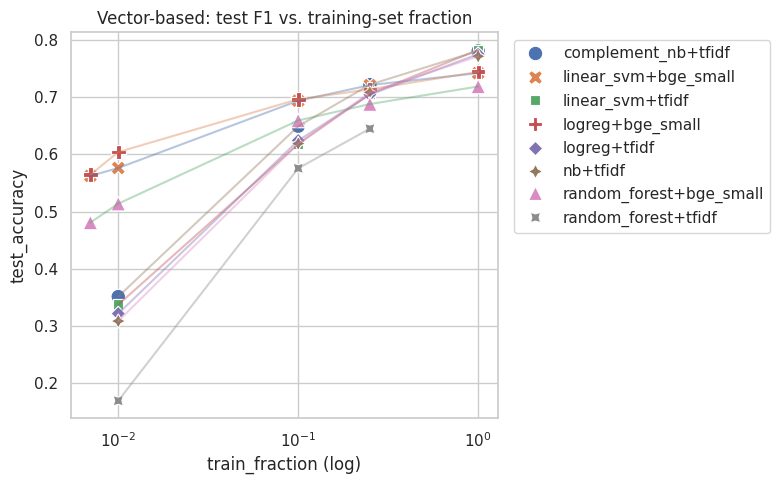

In [29]:
# Per-variant scatter — vector-based
if not vec.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(
        data=vec, x='train_fraction', y='test_accuracy', hue='variant',
        style='variant', s=110, ax=ax,
    )
    sns.lineplot(
        data=vec.sort_values('train_fraction'),
        x='train_fraction', y='test_accuracy', hue='variant',
        legend=False, ax=ax, alpha=0.4,
    )
    ax.set_xscale('log')
    ax.set_xlabel('train_fraction (log)')
    ax.set_ylabel('test_accuracy')
    ax.set_title('Vector-based: test F1 vs. training-set fraction')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> **Caveat — Claude runs use a smaller test set.** Claude runs (`model == claude_sonnet`, from `artifacts/_claude_eval/`) are scored on a balanced subset of `test_per_category × n_classes` documents, whereas the Qwen and vector-based runs use the full ~3770-doc held-out test set. Claude `n_test` and `test_accuracy` are therefore *indicative* and not measured on the identical test set — treat cross-family comparisons accordingly.

## Leaderboard — LLM few-shot across `n_per_category`

In [30]:
llm = runs[is_llm].copy()
llm_board = (
    llm.sort_values(['model', 'n_per_category'])
       [[
           'model', 'llm_tag', 'prompts', 'n_per_category', 'summary_fraction',
           'test_f1_macro', 'test_accuracy', 'test_f1_weighted', 'n_test', 'run',
       ]]
       .reset_index(drop=True)
)
llm_board.style.background_gradient(
    subset=['test_f1_macro', 'test_accuracy', 'test_f1_weighted'], cmap='Purples'
).format({
    'summary_fraction': '{:.2f}',
    'test_f1_macro': '{:.4f}',
    'test_accuracy': '{:.4f}',
    'test_f1_weighted': '{:.4f}',
})

,model,llm_tag,prompts,n_per_category,summary_fraction,test_f1_macro,test_accuracy,test_f1_weighted,n_test,run
0,claude_sonnet,claude-sonnet-4-6,zero_shot_v1,0.000000,0.25,0.7246,0.7164,0.7245,2000,claude_sonnet_zero_shot_v1_n0_summary0.25_20ng
1,claude_sonnet,claude-sonnet-4-6,few_shot_v1,1.000000,0.25,0.7344,0.7299,0.7343,2000,claude_sonnet_few_shot_v1_n1_summary0.25_20ng
2,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.10,0.4508,0.4679,0.4608,3770,qwen25_7b_zero_shot_v1_n0_summary0.1_20ng
3,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.25,0.4650,0.4767,0.4749,3770,qwen25_7b_zero_shot_v1_n0_summary0.25_20ng
4,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.50,0.4608,0.4775,0.4712,3770,qwen25_7b_zero_shot_v1_n0_summary0.5_20ng
5,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.75,0.4737,0.4902,0.4835,3770,qwen25_7b_zero_shot_v1_n0_summary0.75_20ng
6,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,1.00,0.4769,0.4966,0.4870,3770,qwen25_7b_zero_shot_v1_n0_summary1.0_20ng
7,qwen25_7b,qwen2.5:7b-instruct,few_shot_v1,1.000000,0.10,0.5085,0.5127,0.5182,3770,qwen25_7b_few_shot_v1_n1_summary0.1_20ng
8,qwen25_7b,qwen2.5:7b-instruct,few_shot_v1,1.000000,0.25,0.5024,0.5074,0.5113,3770,qwen25_7b_few_shot_v1_n1_summary0.25_20ng
9,qwen25_7b,qwen2.5:7b-instruct,few_shot_v1,1.000000,0.50,0.5230,0.5220,0.5333,3770,qwen25_7b_few_shot_v1_n1_summary0.5_20ng


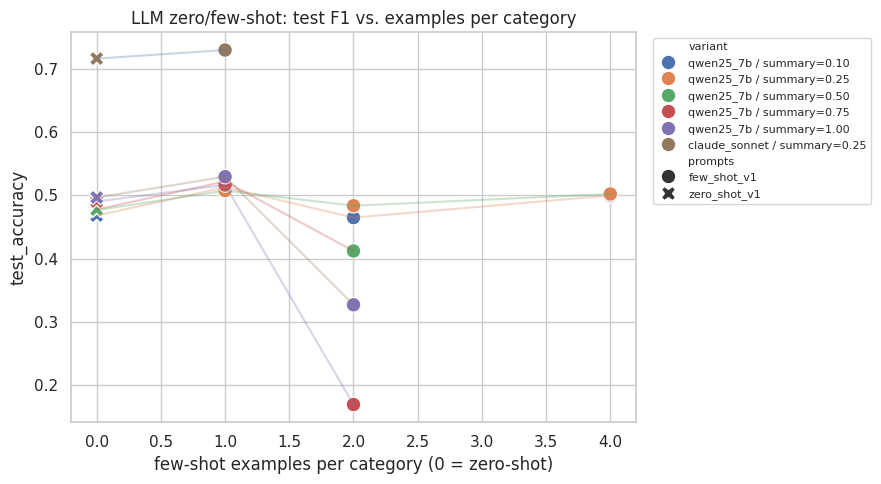

In [31]:
# Per-(model, summary_fraction) scatter — LLM zero/few-shot
if not llm.empty:
    llm_plot = llm.copy()
    llm_plot['variant'] = (
        llm_plot['model'].astype(str)
        + ' / summary='
        + llm_plot['summary_fraction'].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA')
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.scatterplot(
        data=llm_plot, x='n_per_category', y='test_accuracy',
        hue='variant', style='prompts', s=110, ax=ax,
    )
    for _, sub in llm_plot.groupby('variant'):
        sub = sub.sort_values('n_per_category')
        if len(sub) > 1:
            ax.plot(sub['n_per_category'], sub['test_accuracy'], alpha=0.3)
    ax.set_xlabel('few-shot examples per category (0 = zero-shot)')
    ax.set_ylabel('test_accuracy')
    ax.set_title('LLM zero/few-shot: test F1 vs. examples per category')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

## Combined: test F1 vs. training samples per category

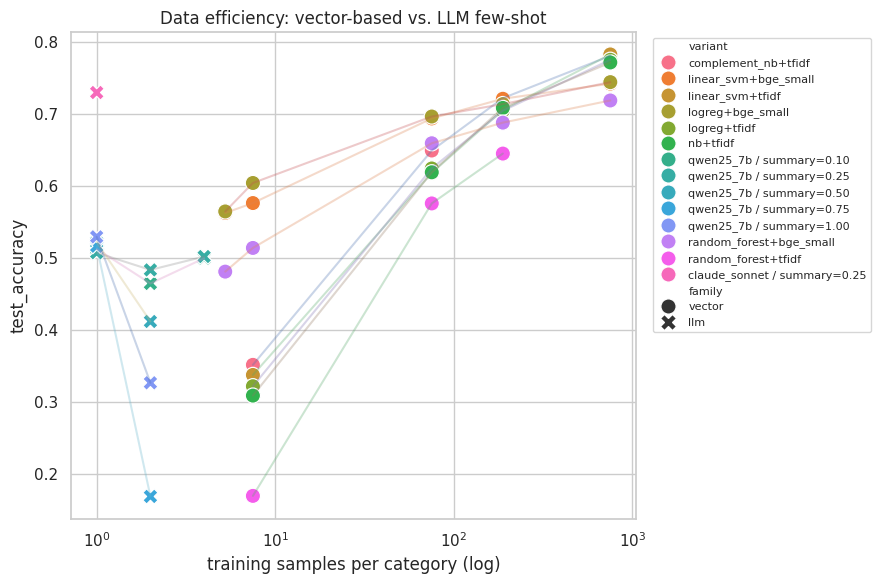

In [32]:
combo = runs[runs['samples_per_category'].notna() & runs['test_f1_macro'].notna()].copy()
combo = combo[combo['samples_per_category'] > 0]

# Re-derive variant so LLM runs are grouped by (model, summary_fraction)
combo['variant'] = np.where(
    combo['family'] == 'vector',
    combo['model'].astype(str) + '+' + combo['featurizer'].astype(str),
    combo['model'].astype(str)
        + ' / summary='
        + combo['summary_fraction'].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA'),
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=combo, x='samples_per_category', y='test_accuracy',
    hue='variant', style='family', s=120, ax=ax,
)
for variant, sub in combo.groupby('variant'):
    sub = sub.sort_values('samples_per_category')
    if len(sub) > 1:
        ax.plot(sub['samples_per_category'], sub['test_accuracy'], alpha=0.3)
ax.set_xscale('log')
ax.set_xlabel('training samples per category (log)')
ax.set_ylabel('test_accuracy')
ax.set_title('Data efficiency: vector-based vs. LLM few-shot')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()